In [ ]:
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import LabelEncoder

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df=pd.read_csv("/content/BreastCancerDataset.csv")

In [ ]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [ ]:
df.isnull().sum() #Null values not present in dataset.

,0
id,0
diagnosis,0
radius_mean,0
texture_mean,0
perimeter_mean,0
area_mean,0
smoothness_mean,0
compactness_mean,0
concavity_mean,0
concave points_mean,0


In [ ]:
df.head(15)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.26540,0.4601,0.11890,<bound method Series.median of 0 NaN\n1 ...
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.18600,0.2750,0.08902,<bound method Series.median of 0 NaN\n1 ...
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.24300,0.3613,0.08758,<bound method Series.median of 0 NaN\n1 ...
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.25750,0.6638,0.17300,<bound method Series.median of 0 NaN\n1 ...
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.16250,0.2364,0.07678,<bound method Series.median of 0 NaN\n1 ...
5,843786,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,...,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.17410,0.3985,0.12440,<bound method Series.median of 0 NaN\n1 ...
6,844359,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,...,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.19320,0.3063,0.08368,<bound method Series.median of 0 NaN\n1 ...
7,84458202,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,...,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.15560,0.3196,0.11510,<bound method Series.median of 0 NaN\n1 ...
8,844981,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,...,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.20600,0.4378,0.10720,<bound method Series.median of 0 NaN\n1 ...
9,84501001,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,...,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.22100,0.4366,0.20750,<bound method Series.median of 0 NaN\n1 ...


In [ ]:
#median=df['Unnamed: 32'].median
#median
#df['Unnamed: 32']=df['Unnamed: 32'].fillna(median)

In [ ]:
X=df.drop(columns=['id','diagnosis','Unnamed: 32'],axis=1)
Y=df['diagnosis']

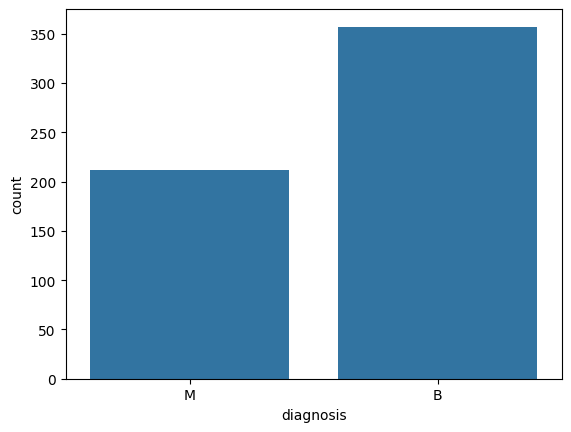

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y = le.fit_transform(df['diagnosis']) 		#diagnosis
Y #1-Malignant(cancerous) 0-Benign(non-cancerous)

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 1, 1,
       0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,

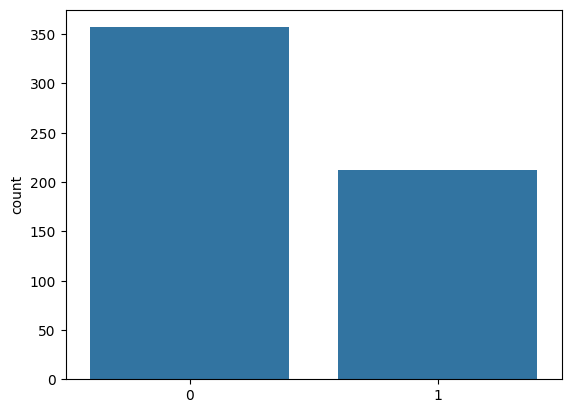

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y)
plt.show() #1-Malignant(cancerous) 0-Benign(non-cancerous)
#M(cancerous)------------1
#B(noncancerous)------------0

In [ ]:
path = "/content/BreastCancerPreprocessor.pkl"
try:
    with open(path, "rb") as f:
        preprocessor = pickle.load(f)
    print("Preprocessor loaded successfully!")
except Exception as e:
    print(f"Failed to load preprocessor: {e}")

Preprocessor loaded successfully!


In [ ]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.20,random_state=42)
X_train.head()

,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,fractal_dimension_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
68,9.029,17.33,58.79,250.5,0.10660,0.14130,0.31300,0.04375,0.2111,0.08046,...,10.31,22.65,65.50,324.7,0.14820,0.43650,1.25200,0.17500,0.4228,0.11750
181,21.090,26.57,142.70,1311.0,0.11410,0.28320,0.24870,0.14960,0.2395,0.07398,...,26.68,33.48,176.50,2089.0,0.14910,0.75840,0.67800,0.29030,0.4098,0.12840
63,9.173,13.86,59.20,260.9,0.07721,0.08751,0.05988,0.02180,0.2341,0.06963,...,10.01,19.23,65.59,310.1,0.09836,0.16780,0.13970,0.05087,0.3282,0.08490
248,10.650,25.22,68.01,347.0,0.09657,0.07234,0.02379,0.01615,0.1897,0.06329,...,12.25,35.19,77.98,455.7,0.14990,0.13980,0.11250,0.06136,0.3409,0.08147
60,10.170,14.88,64.55,311.9,0.11340,0.08061,0.01084,0.01290,0.2743,0.06960,...,11.02,17.45,69.86,368.6,0.12750,0.09866,0.02168,0.02579,0.3557,0.08020


In [ ]:
with open("/content/BreastCancerPreprocessor.pkl","rb") as f:
  preprocessor=pickle.load(f)

In [ ]:
preprocessor

ColumnTransformer(transformers=[('Standard_scaler', StandardScaler(),
                                 ['radius_mean', 'texture_mean',
                                  'perimeter_mean', 'area_mean',
                                  'smoothness_mean', 'compactness_mean',
                                  'concavity_mean', 'concave points_mean',
                                  'symmetry_mean', 'fractal_dimension_mean',
                                  'radius_se', 'texture_se', 'perimeter_se',
                                  'area_se', 'smoothness_se', 'compactness_se',
                                  'concavity_se', 'concave points_se',
                                  'symmetry_se', 'fractal_dimension_se',
                                  'radius_worst', 'texture_worst',
                                  'perimeter_worst', 'area_worst',
                                  'smoothness_worst', 'compactness_worst',
                                  'concavity_worst', 'concave points_worst',
                                  'symmetry_worst',
                                  'fractal_dimension_worst'])])

In [ ]:
Preprocessed_X_train=preprocessor.fit_transform(X_train)
Preprocessed_X_train[2]

array([-1.39998202, -1.24962228, -1.34520926, -1.10978518, -1.33264483,
       -0.30735463, -0.36555756, -0.69650228,  1.93033305,  0.95437877,
        0.02752055,  1.96305996, -0.12095781, -0.35077918,  0.57276579,
        0.7394992 ,  0.32065553,  0.58946222,  2.61504052,  0.71892779,
       -1.29528358, -1.04081128, -1.24522047, -0.99971493, -1.43869328,
       -0.54856427, -0.64491059, -0.97023893,  0.59760192,  0.0578942 ])

In [ ]:
Preprocessed_X_test=preprocessor.transform(X_test)

In [ ]:
Y_train

array([0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0,
       0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0,
       1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 1,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0,
       0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0,
       1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1,
       1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 0, 0,

In [ ]:
smote=SMOTE()
X_train_smote,Y_train_smote=smote.fit_resample(Preprocessed_X_train,Y_train)

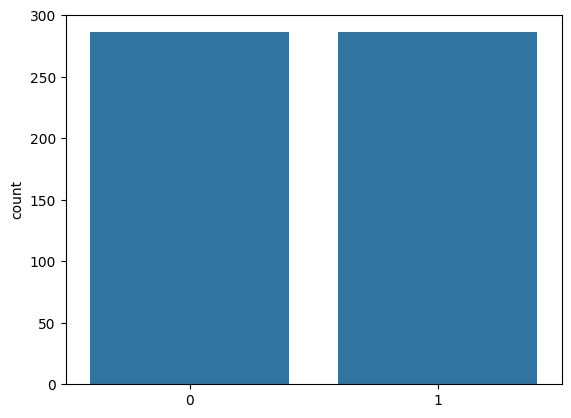

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x=Y_train_smote)
plt.show()
#1---------Malignant(cancerous)
#0----------Benign(non-cancerous)

In [ ]:
#Y_train_smote.value_counts()

Creating and training the model.

In [ ]:
from sklearn.svm import SVC
svclassifier = SVC() ## base model with default parameters
svclassifier.fit(X_train_smote,Y_train_smote)

SVC()

In [ ]:
y_predict=svclassifier.predict(Preprocessed_X_test)
y_predict #1-Malignant(cancerous) 0-Benign(non-cancerous)

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [ ]:
#y_predict=y_predict.replace({0:"beningn",1:"Malignant"})
y_cat_variable = pd.Categorical(y_predict).rename_categories({0:"Benign", 1:"Malignant"})
y_cat_variable

['Benign', 'Malignant', 'Malignant', 'Benign', 'Benign', ..., 'Benign', 'Malignant', 'Benign', 'Benign', 'Malignant']
Length: 114
Categories (2, object): ['Benign', 'Malignant']

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score,f1_score
acc=accuracy_score(y_predict,Y_test)
print("Accuracy Score is",acc)

Accuracy Score is 0.9736842105263158


In [ ]:
recall_score=recall_score(y_predict,Y_test)
recall_score

0.9761904761904762

In [ ]:
f1_score=f1_score(y_predict,Y_test)
f1_score

0.9647058823529412

In [ ]:
print(classification_report(y_predict,Y_test))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        72
           1       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



Hyperparameter Tuning of Support Vector Machine.

In [ ]:
from itertools import product  # Importing the product function from itertools module
params_grid = {
    'C': [0.1,5,10,50,60,70],
    'kernel': ['linear','rbf','poly'], #Kernel could be linear kernel,Radial Basic Function or Polynomial kernel
    'gamma': ['scale', 'auto']
}
#C increases error also increases.

In [ ]:
from sklearn.model_selection import GridSearchCV
svcclassifier=SVC()
grid_svc_cv=GridSearchCV(estimator=svcclassifier,param_grid=params_grid,scoring="f1",n_jobs=-1,verbose=2,cv=2)
grid_svc_cv.fit(X_train_smote,Y_train_smote)

Fitting 2 folds for each of 36 candidates, totalling 72 fits


GridSearchCV(cv=2, estimator=SVC(), n_jobs=-1,
             param_grid={'C': [0.1, 5, 10, 50, 60, 70],
                         'gamma': ['scale', 'auto'],
                         'kernel': ['linear', 'rbf', 'poly']},
             scoring='f1', verbose=2)

In [ ]:
print(grid_svc_cv.best_params_)
#grid_svc_best_params = grid_svc_cv.best_params_       # it will give you best parameters
#print(f"Best paramters: {grid_svc_best_params})")

{'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}


In [ ]:
from sklearn.model_selection import GridSearchCV
svcclassifier=SVC(C=0.1, gamma='scale',kernel='linear') #Fitting best parameters found through grid search.

In [ ]:
svclassifier.fit(X_train_smote,Y_train_smote)

SVC()

In [ ]:
Y_Pred=svclassifier.predict(Preprocessed_X_test)
Y_Pred

array([0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0,
       1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 1])

In [ ]:
y_cat_variable = pd.Categorical(Y_Pred).rename_categories({0:"Benign", 1:"Malignant"})
y_cat_variable

['Benign', 'Malignant', 'Malignant', 'Benign', 'Benign', ..., 'Benign', 'Malignant', 'Benign', 'Benign', 'Malignant']
Length: 114
Categories (2, object): ['Benign', 'Malignant']

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix,classification_report,recall_score,f1_score
acc=accuracy_score(y_predict,Y_test)
print("Accuracy Score is",acc)

Accuracy Score is 0.9736842105263158


In [ ]:
recall=recall_score(Y_Pred,Y_test)
recall

0.9761904761904762

In [ ]:
f1_score=f1_score(Y_Pred,Y_test)
f1_score

0.9647058823529412

In [ ]:
print(classification_report(Y_Pred,Y_test))

              precision    recall  f1-score   support

           0       0.99      0.97      0.98        72
           1       0.95      0.98      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

